----------------------------------------------------------------------------------------------------

# ***Encapsulamento***

----------------------------------------------------------------------------------------------------

O Encapsulamento é um dos quatro pilares da Programação Orientada a Objetos. Em termos simples, ele serve para esconder os detalhes internos de um objeto e expor apenas o que é necessário.

Imagine um Controle Remoto: você tem botões para "Aumentar Volume" ou "Trocar Canal" (Interface Pública), mas você não precisa saber como os circuitos eletrônicos lá dentro funcionam (Detalhes Internos/Privados). Mais do que isso, o fabricante não quer que você mexa nos fios internos, pois você pode quebrar o aparelho.

----------------------------------------------------------------------------------------------------

## ***1. O Conceito Geral: Público vs. Privado***

Na maioria das linguagens (como Java ou C++), o encapsulamento é rígido e imposto pelo compilador através de palavras-chave:

- Public: Qualquer um acessa.

- Private: Só a própria classe acessa.

- Protected: A classe e suas filhas acessam.

----------------------------------------------------------------------------------------------------

## ***2. A Diferença Crucial no Python***

Aqui está o "pulo do gato": O Python não tem modificadores de acesso obrigatórios. O Python segue a filosofia de que "somos todos adultos responsáveis" (we are all consenting adults).

Isso significa que o Python não vai te impedir fisicamente de acessar um atributo privado, mas ele usa convenções de nomenclatura para indicar como aquele dado deve ser tratado.

### ***A) Público (Sem underline)***
Atributos e métodos normais. Podem ser lidos e alterados de qualquer lugar.

In [ ]:
class Conta:
    def __init__(self, saldo):
        self.saldo = saldo # Público

### ***B) Protegido (Um underline: _ )***

É apenas um sinal de "por favor, não mexa aqui, a menos que saiba o que está fazendo". Ele indica que o atributo é para uso interno da classe e suas sub

In [ ]:
class Conta:
    def __init__(self, saldo):
        self._saldo = saldo # Protegido (Convenção)

### ***C) Privado (Dois underlines: __ )***
Quando você usa dois underlines, o Python ativa um mecanismo chamado Name Mangling (Desfiguração de Nome). Ele altera o nome do atributo internamente para dificultar o acesso acidental por fora da classe.

In [ ]:
class Conta:
    def __init__(self, saldo):
        self.__saldo = saldo # Privado (Name Mangling)

c = Conta(1000)
# print(c.__saldo)  # Isso daria ERRO!
# O nome real na memória vira: _Conta__saldo

----------------------------------------------------------------------------------------------------

## ***3. Getters e Setters (O jeito Pythonico: @property)***

Em outras linguagens, você cria métodos como **getSaldo()** e **setSaldo()**. No Python, usamos o decorador **@property** para manter o código limpo. Ele permite que você use um método como se fosse um atributo comum, mas com lógica de proteção por trás.

In [ ]:
class Conta:
    def __init__(self, saldo):
        self.__saldo = saldo

    @property
    def saldo(self):
        """Getter: permite ler o saldo"""
        return self.__saldo

    @saldo.setter
    def saldo(self, valor):
        """Setter: permite alterar com validação"""
        if valor < 0:
            print("Erro: Saldo não pode ser negativo!")
        else:
            self.__saldo = valor

minha_conta = Conta(1000)
print(minha_conta.saldo)  # Usa o @property (Getter)
minha_conta.saldo = -50   # Usa o @saldo.setter (Bloqueia a alteração)

----------------------------------------------------------------------------------------------------

## ***4. Por que encapsular?***

1. ***Proteção de Dados:*** Impede que o saldo de uma conta seja alterado para um valor inválido acidentalmente.

2. ***Flexibilidade:*** Se no futuro você mudar como o saldo é calculado (ex: adicionar juros automáticos), você só muda o código dentro da classe, e quem usa a classe nem percebe a mudança.

3. ***Redução de Acoplamento:*** O mundo exterior não depende de como você guardou os dados, apenas de como você os entrega.

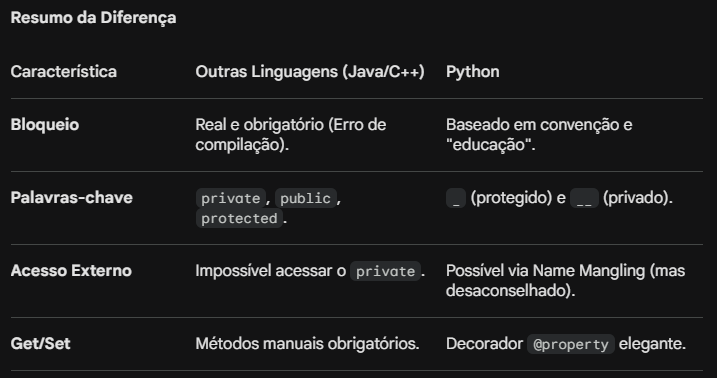